In [1]:
# import tarfile
# with tarfile.open('data/oxford-iiit-pet.tgz', 'r:gz') as tar:
#     tar.extractall(path = './oxford_data', filter='data')

In [1]:
import torch

if torch.cuda.is_available():
    print(f"GPU is available: {torch.cuda.get_device_name(0)}")
    print(f"Total GPUs: {torch.cuda.device_count()}")
else:
    print("GPU not available. Using CPU.")

GPU is available: Tesla T4
Total GPUs: 1


In [ ]:
import os
import sys
from PIL import Image
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset
import torchvision.transforms as T
from torch.utils.data import random_split, DataLoader
from torchvision.utils import make_grid
from src.final_project.DL_Classes import ImageClassificationBase
from torchvision import models
import torch.nn as nn
from tqdm.notebook import tqdm
sys.path.append('..')

In [ ]:
import os
import xml.etree.ElementTree as ET

DATA_DIR = '../Data/oxford-iiit-pet/annotations/xmls/'
files = os.listdir(DATA_DIR)

# Get the first file name
first_file = files[7]

# Combine the directory path and the file name
full_path = os.path.join(DATA_DIR, first_file)

# Parse using the correct full path
tree = ET.parse(full_path)
root = tree.getroot()

object_name = root.find('object/name').text

print(object_name)  # Output: dog

['Abyssinian_1.jpg',
 'Abyssinian_10.jpg',
 'Abyssinian_100.jpg',
 'Abyssinian_100.mat',
 'Abyssinian_101.jpg']

In [ ]:
DATA_DIR = '../Data/oxford-iiit-pet/images/'

files = os.listdir(DATA_DIR)
files[:5]

'american_bulldog_97.jpg'

In [ ]:
files[400]

In [5]:
def parse_breed(fname):
    parts = fname.split('_')
    return ' '.join(parts[:-1])

parse_breed(files[400])

'american bulldog'

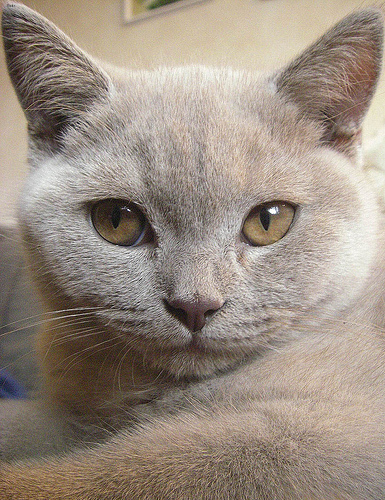

In [6]:
def open_image(path):

    with open(path, 'rb') as f:
        img = Image.open(f)
        return img.convert('RGB')

open_image(DATA_DIR + files[1900])

In [7]:
parse_breed(DATA_DIR + files[500])

'oxford data/oxford-iiit-pet/images/american pit bull terrier'

In [8]:
class PetsDataset(Dataset):
    def __init__(self, root, transform):
        super().__init__()
        self.root = root
        self.files = [fname for fname in os.listdir(root) if fname.endswith('.jpg')]
        self.classes = list(set(parse_breed(fname) for fname in files))
        self.transform = transform

    
    def __len__(self):
        return len(self.files)
    
    def __getitem__(self, idx):
        fname = self.files[idx]
        fpath = os.path.join(self.root, fname)
        img = self.transform(open_image(fpath))
        class_idx = self.classes.index(parse_breed(fname))

        return img, class_idx

In [9]:
DATA_DIR

'oxford_data/oxford-iiit-pet/images/'

In [10]:
img_size = 224

imagenet_stats = ([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])

dataset = PetsDataset(DATA_DIR, T.Compose([T.Resize(img_size),
                      T.Pad(8, padding_mode='reflect'),
                      T.RandomCrop(img_size),
                      T.ToTensor (),
                      T.Normalize(*imagenet_stats) ]))

In [11]:
def denormalize(images, means, stds):
    if len(images.shape) == 3:
        images = images.unsqueeze(0)
    means = torch.tensor(means).reshape(1, 3, 1, 1)
    stds = torch.tensor(stds).reshape(1, 3, 1, 1)
    return images * stds + means

def show_image(img_tensor, label):
    print('Label:', dataset.classes[label], '('+ str(label) + ')')
    img_tensor = denormalize(img_tensor, *imagenet_stats)[0].permute((1, 2,0))
    plt.imshow(img_tensor)

Label: Abyssinian (4)


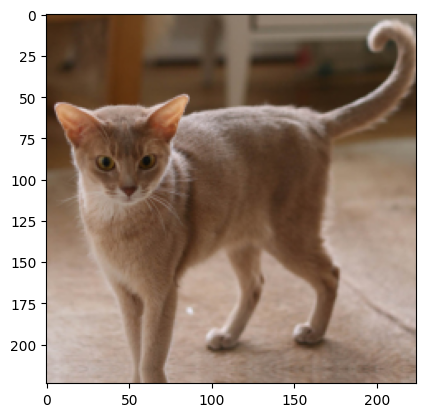

In [12]:
show_image(*dataset[20])

In [13]:
val_pct = 0.1

val_size = int(val_pct * len(dataset))
train_size = len(dataset) - val_size
train_ds, valid_ds = random_split(dataset, [train_size, val_size])

In [14]:
batch_size = 128

train_dl = DataLoader(train_ds, batch_size, shuffle=True, num_workers=0, pin_memory=True)
valid_dl = DataLoader(valid_ds, batch_size * 2, num_workers=0, pin_memory=True)


In [15]:
len(dataset.classes)

37

In [16]:
def show_batch(dl):
    for images, labels in dl:
        fig, ax = plt.subplots(figsize=(16,16))
        ax.set_xticks([]); ax.set_yticks([ ])
        images = denormalize(images[:64],*imagenet_stats)
        ax.imshow(make_grid(images, nrow=8).permute(1,2,0))
        break



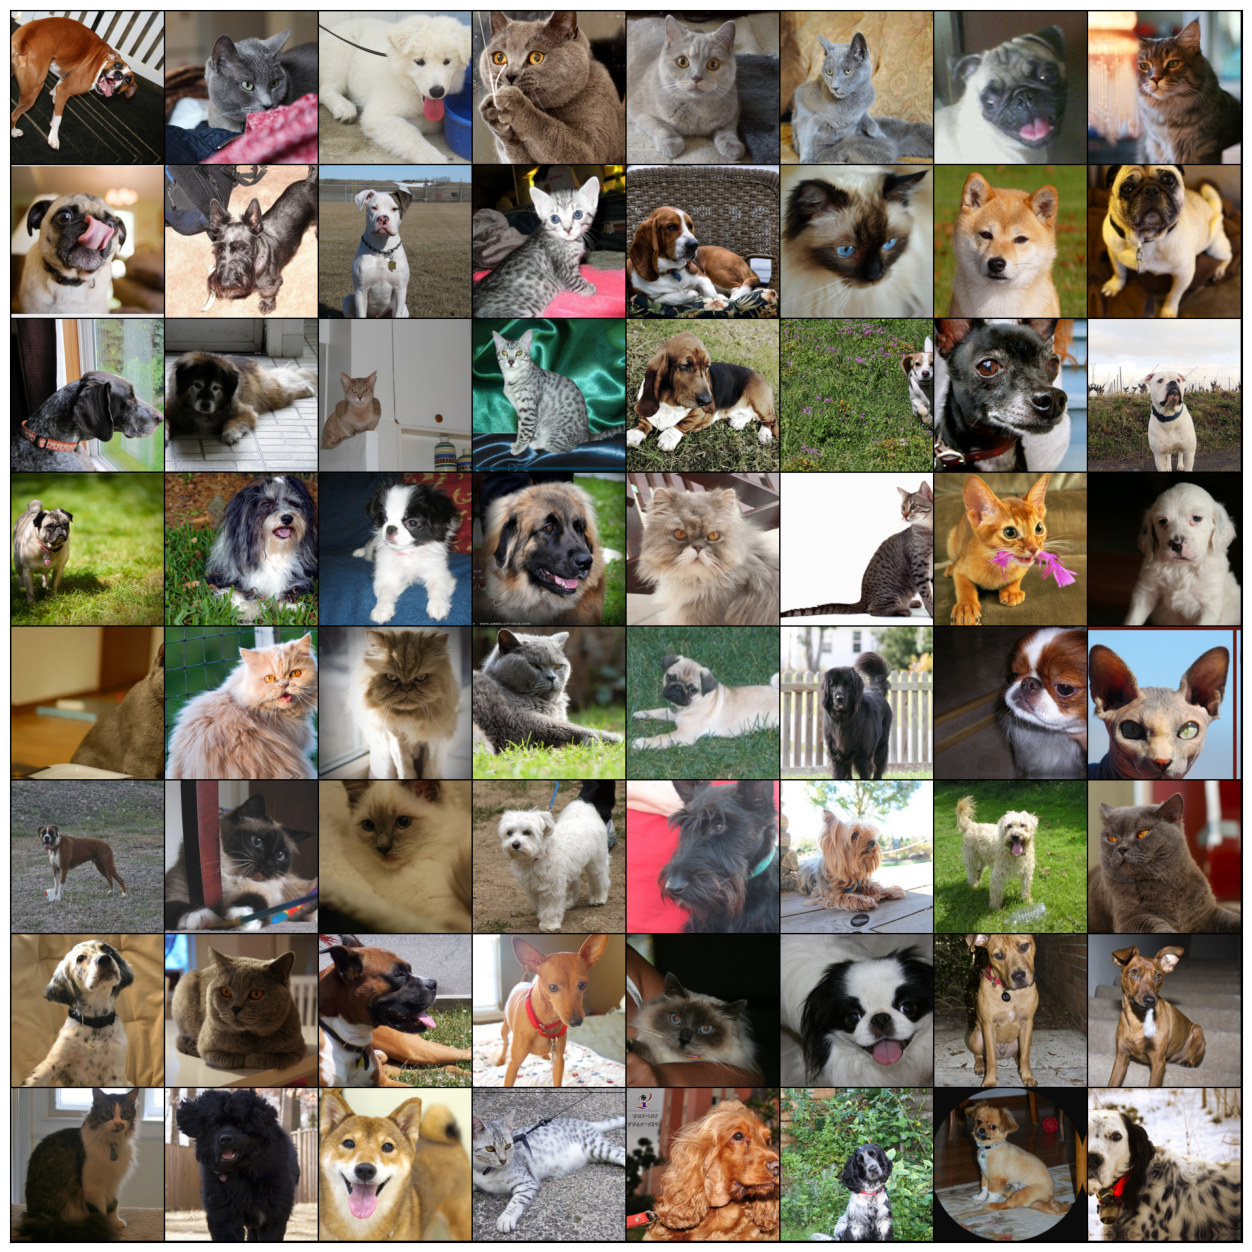

In [17]:
show_batch(train_dl)

In [18]:
resnet = models.resnet34(pretrained=True)

c:\Users\X-COMPUTER\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\X-COMPUTER\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
class PetsModel(ImageClassificationBase):
    def __init__(self, num_classes, pretrained=True):
        super().__init__()

        # Use pretrained model
        self.network = models.resnet34(pretrained=pretrained)
        # Replace last layer
        self.network.fc = nn.Linear(self.network.fc.in_features, num_classes)

    def forward(self, xb):
        return self.network(xb)

In [20]:
def get_default_device():
    if torch.cuda.is_available():
        return torch.device('cuda')

    else:
        return torch.device('cpu')

device = get_default_device()

def to_device(data, device):
    if isinstance(data, (list, tuple)):
        return [to_device(x, device) for x in data]
    return data.to(device, non_blocking=(device.type == 'cuda'))

class DeviceDataLoader():

    def __init__(self, dl, device):
        self.dl = dl
        self.device = device

    def __iter__(self):
        for b in self.dl:
            yield to_device(b, self.device)

    def __len__(self):
        return len(self.dl)
    
trainloader = DeviceDataLoader(train_dl, device)
valloader = DeviceDataLoader(valid_dl, device)

In [21]:
@torch.no_grad()
def evaluate(model, val_loader):
    """Evaluate the model's performance on the validation set."""
    model.eval()
    outputs = [model.validation_step(batch) for batch in val_loader]
    return model.validation_epoch_end(outputs)

In [22]:
def fit(epochs, lr, model, train_loader, val_loader, opt_func=torch.optim.SGD):

    history = []
    optimizer = opt_func(model.parameters(), lr)
    for epoch in range(epochs) :
        # Training Phase
        model.train()
        train_losses = []
        train_accs = []
        for batch in tqdm(train_loader):
            loss, acc = model.training_step(batch)
            train_losses.append(loss)
            train_accs.append(acc)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

        result = evaluate(model, val_loader)
        result['train_loss'] = torch.stack(train_losses).mean().item()
        result['train_acc'] = torch.stack(train_accs).mean().item()
        model.epoch_end(epoch, result)
        history.append(result)
    return history


In [23]:
def get_lr(optimizer):
    for param_group in optimizer.param_groups:
        return param_group['lr' ]

def fit_one_cycle(epochs, max_lr, model, train_loader, val_loader,
                  weight_decay=0, grad_clip=None, opt_func=torch.optim.SGD):
    
    torch.cuda.empty_cache()
    history = []

    # Set up custom optimizer with weight decay
    optimizer = opt_func(model.parameters(), max_lr, weight_decay=weight_decay)
    # Set up one-cycle learning rate scheduler
    sched = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr, epochs=epochs,
                                                 steps_per_epoch=len(train_loader))

    for epoch in range(epochs):
        # Training Phase
        model.train()
        train_losses = []
        train_accs = []
        lrs = []
        for batch in tqdm(train_loader):
            loss, acc = model.training_step(batch)
            train_losses.append(loss)
            train_accs.append(acc)
            loss.backward()

            # Gradient clipping
            if grad_clip:
                nn.utils.clip_grad_value_(model.parameters(), grad_clip)

            optimizer.step()
            optimizer.zero_grad()

            lrs.append(get_lr(optimizer))
            sched.step()

        # Validation Phase
        result = evaluate(model, val_loader)
        result['train_loss'] = torch.stack(train_losses).mean().item()
        result['train_acc'] = torch.stack(train_accs).mean().item()
        result['lrs'] = lrs
        model.epoch_end(epoch, result)
        history.append(result)

    return history


In [24]:
model = PetsModel(len(dataset.classes))
to_device(model, device)

PetsModel(
  (network): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_r

In [25]:
history = [evaluate(model, valloader)]
history

[{'val_loss': 3.7900986671447754, 'val_acc': 0.02817547880113125}]

In [ ]:
epochs = 6
max_lr = 0.01
grad_clip = 0.1
weight_decay = 1e-4
opt_func = torch.optim.Adam

history+= fit_one_cycle(epochs, max_lr, model, trainloader, valloader, 
                        weight_decay=weight_decay,
                        grad_clip=grad_clip,
                        opt_func=opt_func)

In [ ]:
model_path = '../artifacts/pets_model_state_dict.pth'
torch.save(model.state_dict(), model_path)
print(f'Model weights saved to {model_path}')

In [ ]:
!pip install --upgrade onnx onnxscript